# 01 | What does geospatial data look like?
**35 minutes · Table → geometry → map → file format**

**By the end:** recognize points, lines, polygons and grids; inspect five common formats; build a map from longitude and latitude.

**Case question:** How can we connect an asset spreadsheet to information about its surroundings?
All portfolio features are synthetic. We build on DataFrames and plotting; geometry and coordinate systems are introduced here.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Works when Jupyter starts in the project root or a subfolder.
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'data/assets.csv').exists()), None)
if ROOT is None:
    raise FileNotFoundError('Keep the notebooks and data folders together; open this project in Jupyter.')
DATA = ROOT / 'data'
OUT = ROOT / 'outputs'
OUT.mkdir(exist_ok=True)
plt.rcParams.update({'figure.figsize': (9, 5), 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.titleweight': 'bold', 'figure.dpi': 110})
print('Ready. Core lessons use bundled local data; no API key needed.')

Ready. Core lessons use bundled local data; no API key needed.


## 1. Two ways to describe space
**Vector:** distinct objects. A point might represent a warehouse; a line a road; a polygon a service area.
**Raster:** a grid of cells. Each cell holds a value, such as temperature or a sensor reading. A raster can have multiple bands, and a climate dataset can add a time dimension.

A **format** is the container, not a guarantee of quality. A beautifully mapped CSV can still contain a wrong address.

In [2]:
import geopandas as gpd
assets = pd.read_csv(DATA / 'assets.csv')
display(assets.head(3))

# GeoJSON and points_from_xy use longitude (x) first, then latitude (y).
points = gpd.GeoDataFrame(assets,
    geometry=gpd.points_from_xy(assets.longitude, assets.latitude), crs='EPSG:4326')
display(points[['asset_id','geometry']].head(3))
print('CRS:', points.crs)

,asset_id,asset_name,sector,longitude,latitude,equity_usd_m,cooling_backup_verified
0,A01,Bay warehouse,Logistics,-95.48,29.65,20,False
1,A02,Canal apartments,Housing,-95.42,29.70,35,True
2,A03,Cedar logistics,Logistics,-95.33,29.72,28,False


,asset_id,geometry
0,A01,POINT (-95.48 29.65)
1,A02,POINT (-95.42 29.7)
2,A03,POINT (-95.33 29.72)


CRS: EPSG:4326


The **coordinate reference system (CRS)** tells us how numbers correspond to locations on Earth. `EPSG:4326` uses longitude/latitude in degrees here. Longitude is east–west; latitude is north–south. Negative longitude places these example points west of Greenwich.

**Predict:** What happens if the two columns are reversed? A numeric range check is useful, but cannot catch every location mistake.

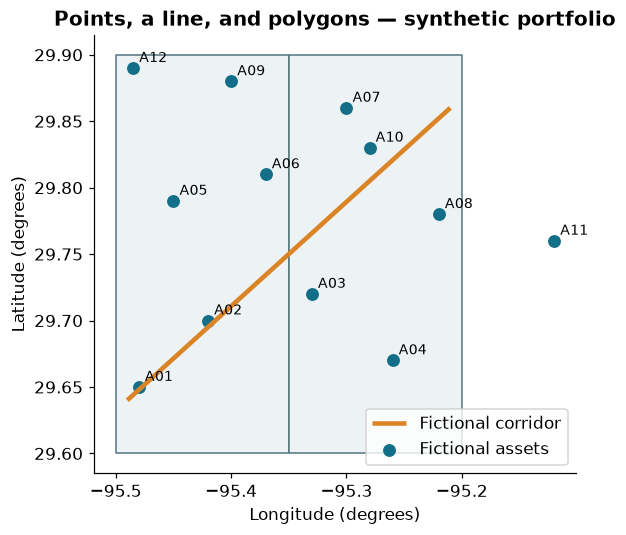

In [3]:
assert points.longitude.between(-180,180).all()
assert points.latitude.between(-90,90).all()
assert points.asset_id.is_unique
zones = gpd.read_file(DATA / 'service_areas.geojson')
roads = gpd.read_file(DATA / 'corridor.geojson')
fig, ax = plt.subplots()
zones.plot(ax=ax, facecolor='#edf3f4', edgecolor='#52757e')
roads.plot(ax=ax, color='#db8426', linewidth=3, label='Fictional corridor')
points.plot(ax=ax, color='#126f87', markersize=55, label='Fictional assets')
for row in points.itertuples():
    ax.annotate(row.asset_id,(row.geometry.x,row.geometry.y),xytext=(4,4),textcoords='offset points',fontsize=9)
ax.set(xlabel='Longitude (degrees)', ylabel='Latitude (degrees)', title='Points, a line, and polygons — synthetic portfolio')
from matplotlib.ticker import MaxNLocator
ax.xaxis.set_major_locator(MaxNLocator(5))
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 2. Open the container
**Predict:** Will GeoJSON look like a spreadsheet or nested text? A **Feature** stores geometry alongside descriptive **properties**. A **FeatureCollection** holds features together.

In [4]:
import json
geojson = json.loads((DATA / 'assets.geojson').read_text())
print(json.dumps(geojson['features'][0], indent=2))

{
  "type": "Feature",
  "properties": {
    "asset_id": "A01",
    "asset_name": "Bay warehouse",
    "sector": "Logistics",
    "longitude": -95.48,
    "latitude": 29.65,
    "equity_usd_m": 20,
    "cooling_backup_verified": false
  },
  "geometry": {
    "type": "Point",
    "coordinates": [
      -95.48,
      29.65
    ]
  }
}


## 3. A small format museum

| Format | Useful mental picture | Often used for | Watch for |
|---|---|---|---|
| CSV | Plain table | Addresses or coordinates, attributes | Geometry and CRS are not automatically encoded |
| GeoJSON | Nested text containing shapes | Small vector datasets and web exchange | Longitude before latitude; large files can be bulky |
| Shapefile | A set of companion files | Legacy vector delivery | Keep `.shp`, `.shx`, `.dbf`, `.prj` and other supplied companions together; field names are limited |
| GeoPackage | One SQLite database file | One or more geospatial layers | Choose the correct layer |
| GeoTIFF | Image/grid with location metadata | Imagery or a mapped measurement | CRS, grid size, units, missing-data marker |
| NetCDF | Named arrays with dimensions and metadata | Time × latitude × longitude climate data | Variable, units, calendar, time aggregation |

You will open actual examples below and in Notebooks 03–04. GeoPackage and NetCDF can store more than the simple examples shown here.

In [5]:
from_geopackage = gpd.read_file(DATA / 'assets.gpkg', layer='assets')
from_shapefile = gpd.read_file(DATA / 'shapefile_example/assets.shp')
display(pd.DataFrame({
    'container':['CSV','GeoJSON','GeoPackage','Shapefile'],
    'features':[len(assets),len(geojson['features']),len(from_geopackage),len(from_shapefile)]}))
print('Shapefile companions:', [p.name for p in sorted((DATA/'shapefile_example').glob('*'))])
print('GeoPackage CRS:', from_geopackage.crs)
assert set(from_geopackage.asset_id) == set(assets.asset_id)

,container,features
0,CSV,12
1,GeoJSON,12
2,GeoPackage,12
3,Shapefile,12


Shapefile companions: ['assets.cpg', 'assets.dbf', 'assets.prj', 'assets.shp', 'assets.shx']
GeoPackage CRS: EPSG:4326


## Try it · 5 minutes
1. Show only housing assets on the map. Does filtering change the geography or only the selected records?
2. Choose a file format for (a) sharing 12 asset locations, (b) handing over several boundary layers, (c) storing daily temperature for 30 years.
3. A supplier sends only `assets.shp`. What would you request?

**Coding extension:** export a filtered GeoJSON into `outputs/` with `points.to_file(...)`, reload it and check IDs and CRS. Add a coordinate-quality check for missing values and the expected study extent; explain why global latitude/longitude bounds alone are insufficient.

**Takeaway:** location is data, not decoration. Inspect geometry, metadata and attributes before trusting the map.

Sources: [GeoJSON specification](https://www.rfc-editor.org/rfc/rfc7946), [GeoPackage](https://www.ogc.org/standards/geopackage/), [GeoTIFF](https://www.ogc.org/standards/geotiff/), [NetCDF](https://docs.unidata.ucar.edu/nug/current/).